In [30]:
!pip install faker

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   -------------------- ------------------- 1.0/2.0 MB 5.3 MB/s eta 0:00:01
   ------------------------------------ --- 1.8/2.0 MB 5.7 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 3.3 MB/s  0:00:00


In [37]:
import kagglehub
import pandas as pd
import os
import requests
import zipfile
import io
from faker import Faker

In [ ]:
# Exercice 1

# 1. Téléchargement
path = kagglehub.dataset_download("arunjangir245/boston-housing-dataset")

# 2. On liste les fichiers pour trouver le nom du CSV
files = os.listdir(path)
print("Fichiers trouvés :", files)

# 3. On charge le premier fichier CSV trouvé
csv_path = os.path.join(path, files[0])
df = pd.read_csv(csv_path)

print(df.head())
print()
# descrition of column "age"
print(df['age'].describe())

Fichiers trouvés : ['BostonHousing.csv']
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  
count    506.000000
mean      68.574901
std       28.148861
min        2.900000
25%       45.025000
50%       77.500000
75%       94.075000
max      100.000000
Name: age, dtype: float64


In [ ]:
# Exercise 2: Comparative Analysis of Retail Data

# --- 1. Chargement du Retail Dataset (Données structurées) ---
url_retail = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D3%20-%20Importing%20Data,%20Exporting%20D/Retail%20Data%20Analytics%20dataset.zip"

response = requests.get(url_retail)
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    # On liste les fichiers pour voir les noms exacts
    print("Fichiers dans Retail ZIP:", z.namelist())
    
    # On charge les 3 fichiers séparément car ils sont complémentaires
    df_features = pd.read_csv(z.open('Retail Data Analytics dataset/Features data set.csv'))
    df_sales = pd.read_csv(z.open('Retail Data Analytics dataset/sales data-set.csv'))
    df_stores = pd.read_csv(z.open('Retail Data Analytics dataset/stores data-set.csv'))

# --- 2. Chargement du Women's E-Commerce (Données non-structurées) ---
url_reviews = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D3%20-%20Importing%20Data,%20Exporting%20D/Women's%20E-Commerce%20Clothing%20Reviews.zip"

response_rev = requests.get(url_reviews)
with zipfile.ZipFile(io.BytesIO(response_rev.content)) as z:
    print("Fichiers dans Reviews ZIP:", z.namelist())
    # On charge le fichier CSV principal (ajuste le nom si nécessaire selon le print)
    df_unstructured = pd.read_csv(z.open(z.namelist()[0]))

# Affichage des résultats
print("\nStructure du dataset Sales :")
print(df_sales.head())
print("\nStructure du dataset Reviews :")
print(df_unstructured.head())

Fichiers dans Retail ZIP: ['Retail Data Analytics dataset/Features data set.csv', 'Retail Data Analytics dataset/sales data-set.csv', 'Retail Data Analytics dataset/stores data-set.csv']
Fichiers dans Reviews ZIP: ["Women's E-Commerce Clothing Reviews/Womens Clothing E-Commerce Reviews.csv"]

Structure du dataset Sales :
   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  05/02/2010      24924.50      False
1      1     1  12/02/2010      46039.49       True
2      1     1  19/02/2010      41595.55      False
3      1     1  26/02/2010      19403.54      False
4      1     1  05/03/2010      21827.90      False

Structure du dataset Reviews :
   Unnamed: 0  Clothing ID  Age                    Title  \
0           0          767   33                      NaN   
1           1         1080   34                      NaN   
2           2         1077   60  Some major design flaws   
3           3         1049   50         My favorite buy!   
4           4          847   47  

Top 5 des dates avec les plus grosses ventes :
Date
2010-12-24    80931415.60
2011-12-23    76998241.31
2011-11-25    66593605.26
2010-11-26    65821003.24
2010-12-17    61820799.85
Name: Weekly_Sales, dtype: float64

Performance par Type de magasin :
              mean           sum
Type                            
A     20099.568043  4.331015e+09
B     12237.075977  2.000701e+09
C      9519.532538  4.055035e+08


Matplotlib is building the font cache; this may take a moment.


<Axes: title={'center': 'Évolution des ventes hebdomadaires'}, xlabel='Date'>

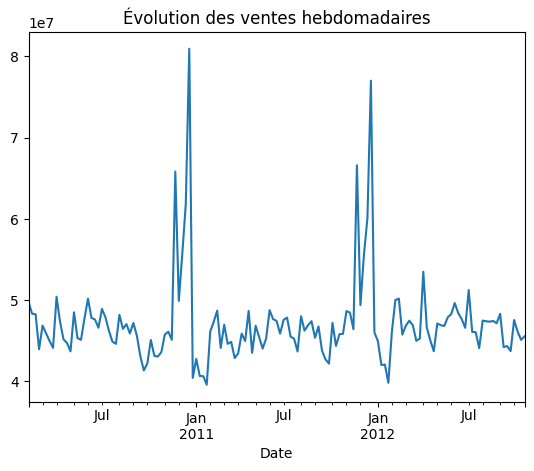

In [19]:
# 1. Préparation des données
# On fusionne les ventes avec les infos des magasins
df_retail_complete = pd.merge(df_sales, df_stores, on='Store')

# Convertir la colonne Date en format datetime pour l'analyse temporelle
df_retail_complete['Date'] = pd.to_datetime(df_retail_complete['Date'], dayfirst=True)

# 2. Analyse des tendances (Sales Trends)
sales_trends = df_retail_complete.groupby('Date')['Weekly_Sales'].sum()
print("Top 5 des dates avec les plus grosses ventes :")
print(sales_trends.sort_values(ascending=False).head())

# 3. Performance par type de magasin
store_perf = df_retail_complete.groupby('Type')['Weekly_Sales'].agg(['mean', 'sum'])
print("\nPerformance par Type de magasin :")
print(store_perf)

# 4. Visualisation simple (Si tu as matplotlib installé)
sales_trends.plot(title="Évolution des ventes hebdomadaires")


In [18]:
# Analyse des Clothing Reviews (Non-structuré)
# 1. Aperçu de la satisfaction (Customer Satisfaction)
avg_rating = df_unstructured['Rating'].mean()
recommend_rate = df_unstructured['Recommended IND'].mean() * 100

print(f"Note moyenne : {avg_rating:.2f}/5")
print(f"Taux de recommandation : {recommend_rate:.1f}%")

# 2. Satisfaction par catégorie de vêtement
cat_perf = df_unstructured.groupby('Class Name')['Rating'].mean().sort_values(ascending=False)
print("\nTop 5 des catégories les mieux notées :")
print(cat_perf.head())

# 3. Extraction basique de sujets (Fréquence de mots dans les avis négatifs)
# On filtre les avis avec une note de 1 ou 2
negative_reviews = df_unstructured[df_unstructured['Rating'] <= 2]['Review Text'].dropna()

# On regarde les mots qui reviennent souvent (approche simplifiée)
all_words = " ".join(negative_reviews).lower().split()
from collections import Counter
common_words = Counter(all_words).most_common(10)
print("\nMots fréquents dans les avis négatifs :", common_words)

Note moyenne : 4.20/5
Taux de recommandation : 82.2%

Top 5 des catégories les mieux notées :
Class Name
Casual bottoms    4.500000
Layering          4.376712
Jeans             4.360942
Lounge            4.301013
Jackets           4.295455
Name: Rating, dtype: float64

Mots fréquents dans les avis négatifs : [('the', 9122), ('i', 5983), ('and', 4630), ('it', 4203), ('a', 3787), ('this', 2745), ('is', 2741), ('to', 2564), ('was', 2368), ('in', 2109)]


In [26]:
# EXERCISE 3 : Basic Data Exploration in E-Commerce
 
# Load the dataset
response = requests.get("https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D3%20-%20Importing%20Data,%20Exporting%20D/E-Commerce%20Dataset.zip")
with zipfile.ZipFile(io.BytesIO(response_rev.content)) as z:
    print("Fichiers dans Reviews ZIP:", z.namelist())
    # On charge le fichier CSV principal (ajuste le nom si nécessaire selon le print)
    df_ecom = pd.read_csv(z.open(z.namelist()[0]))
# Print the first few rows
print("\n--- First 5 rows ---")
print(df_ecom.head())
# Basic information
print("\n--- Basic info ---")
print(df_ecom.info())
 
print("\n--- Data types ---")
print(df_ecom.dtypes)
 
# Identify structured columns
print("\n--- Structured columns ---")
structured_cols = {
    "InvoiceNo":   "Categorical / ID - fixed format identifier",
    "StockCode":   "Categorical - product code",
    "Quantity":    "Numerical (integer) - countable value",
    "InvoiceDate": "Date/time - temporal value",
    "UnitPrice":   "Numerical (float) - monetary value",
    "CustomerID":  "Numerical ID - unique per customer",
    "Country":     "Categorical - fixed set of country names",
}
for col, reason in structured_cols.items():
    print(f"  {col:15s} -> {reason}")
 
print("\n--- Unstructured data that could complement this dataset ---")
print("""
  1. Customer reviews : free-text feedback left after a purchase.
     -> Sentiment analysis on reviews can explain why some products
        sell more or why customers from certain countries return items.
 
  2. Product descriptions : long textual descriptions from the website.
     -> NLP techniques (keyword extraction, topic modelling) can help
        group similar products and improve recommendations.
 
  3. Support chat logs : customer service conversations.
     -> Can reveal common complaints linked to specific StockCodes
        or Countries, helping reduce return rates.
 
  How to combine with structured data:
  - Join reviews on StockCode to measure average sentiment per product.
  - Compare sentiment score with UnitPrice to see if expensive items
    receive better reviews.
  - Use CustomerID to link a customer's review history with their
    purchase frequency and total spend.
""")

Fichiers dans Reviews ZIP: ["Women's E-Commerce Clothing Reviews/Womens Clothing E-Commerce Reviews.csv"]

--- First 5 rows ---
   Unnamed: 0  Clothing ID  Age                    Title  \
0           0          767   33                      NaN   
1           1         1080   34                      NaN   
2           2         1077   60  Some major design flaws   
3           3         1049   50         My favorite buy!   
4           4          847   47         Flattering shirt   

                                         Review Text  Rating  Recommended IND  \
0  Absolutely wonderful - silky and sexy and comf...       4                1   
1  Love this dress!  it's sooo pretty.  i happene...       5                1   
2  I had such high hopes for this dress and reall...       3                0   
3  I love, love, love this jumpsuit. it's fun, fl...       5                1   
4  This shirt is very flattering to all due to th...       5                1   

   Positive Feedback Cou

In [27]:
# Basic information
print("\n--- Basic info ---")
print(df_ecom.info())
 
print("\n--- Data types ---")
print(df_ecom.dtypes)
 
# Identify structured columns
print("\n--- Structured columns ---")
structured_cols = {
    "InvoiceNo":   "Categorical / ID - fixed format identifier",
    "StockCode":   "Categorical - product code",
    "Quantity":    "Numerical (integer) - countable value",
    "InvoiceDate": "Date/time - temporal value",
    "UnitPrice":   "Numerical (float) - monetary value",
    "CustomerID":  "Numerical ID - unique per customer",
    "Country":     "Categorical - fixed set of country names",
}
for col, reason in structured_cols.items():
    print(f"  {col:15s} -> {reason}")
 
print("\n--- Unstructured data that could complement this dataset ---")
print("""
  1. Customer reviews : free-text feedback left after a purchase.
     -> Sentiment analysis on reviews can explain why some products
        sell more or why customers from certain countries return items.
 
  2. Product descriptions : long textual descriptions from the website.
     -> NLP techniques (keyword extraction, topic modelling) can help
        group similar products and improve recommendations.
 
  3. Support chat logs : customer service conversations.
     -> Can reveal common complaints linked to specific StockCodes
        or Countries, helping reduce return rates.
 
  How to combine with structured data:
  - Join reviews on StockCode to measure average sentiment per product.
  - Compare sentiment score with UnitPrice to see if expensive items
    receive better reviews.
  - Use CustomerID to link a customer's review history with their
    purchase frequency and total spend.
""")
 


--- Basic info ---
<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 2.0 MB
None

--- Data types ---
Unnamed: 0                 int64
Clothing ID                int64
Age                        int64
Title                        str
Rev

In [28]:
# EXERCISE 4 : Metro Interstate Traffic Volume
# Load the dataset
response = requests.get("https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D3%20-%20Importing%20Data,%20Exporting%20D/E-Commerce%20Dataset.zip")
with zipfile.ZipFile(io.BytesIO(response_rev.content)) as z:
    print("Fichiers dans Reviews ZIP:", z.namelist())
    # On charge le fichier CSV principal (ajuste le nom si nécessaire selon le print)
    df_metro = pd.read_csv(z.open(z.namelist()[0]))
print("\n--- First 5 rows ---")
print(df_metro.head())
 
print("\n--- Structured elements ---")
structured_metro = {
    "date_time":     "DateTime",
    "traffic_volume": "Integer",
    "temp":           "Float",
    "rain_1h":        "Float",
    "snow_1h":        "Float",
    "clouds_all":     "Integer (percentage 0-100)",
    "holiday":        "Categorical (fixed list of holiday names or None)",
    "weather_main":   "Categorical (fixed set: Clear, Clouds, Rain...)",
}
for col, dtype in structured_metro.items():
    print(f"  {col:25s} -> {dtype}")
 
print("\n--- Categorisation with explanation ---")
print("""
  STRUCTURED:
  - date_time        : precise timestamp, machine-readable, sortable.
  - traffic_volume   : integer count, directly measurable.
  - temp, rain_1h, snow_1h, clouds_all : numeric sensor readings.
  - holiday          : comes from a fixed, predefined list of values.
  - weather_main     : also a controlled vocabulary (Clear, Rain, etc.).
 
  SEMI-STRUCTURED / UNSTRUCTURED:
  - weather_description : free-text field like "light intensity drizzle"
    or "overcast clouds". Although it looks like a short label, its
    content is not strictly controlled and varies in phrasing.
    -> It sits between structured and unstructured because it is
       constrained in practice but not enforced as a strict category.
    -> To use it in a model we would need to encode it (e.g. one-hot)
       or apply text processing.
""")

Fichiers dans Reviews ZIP: ["Women's E-Commerce Clothing Reviews/Womens Clothing E-Commerce Reviews.csv"]

--- First 5 rows ---
   Unnamed: 0  Clothing ID  Age                    Title  \
0           0          767   33                      NaN   
1           1         1080   34                      NaN   
2           2         1077   60  Some major design flaws   
3           3         1049   50         My favorite buy!   
4           4          847   47         Flattering shirt   

                                         Review Text  Rating  Recommended IND  \
0  Absolutely wonderful - silky and sexy and comf...       4                1   
1  Love this dress!  it's sooo pretty.  i happene...       5                1   
2  I had such high hopes for this dress and reall...       3                0   
3  I love, love, love this jumpsuit. it's fun, fl...       5                1   
4  This shirt is very flattering to all due to th...       5                1   

   Positive Feedback Cou

In [29]:
# EXERCISE 5 : MovieLens Ratings Dataset
# Load the dataset
response = requests.get("https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D3%20-%20Importing%20Data,%20Exporting%20D/MovieLens%2020M%20Dataset.zip")
with zipfile.ZipFile(io.BytesIO(response_rev.content)) as z:
    print("Fichiers dans Reviews ZIP:", z.namelist())
    # On charge le fichier CSV principal (ajuste le nom si nécessaire selon le print)
    df_ratings  = pd.read_csv(z.open(z.namelist()[0]))
print("\n--- First 5 rows ---")
print(df_ratings.head())
 
print("\n--- Structured elements ---")
print("""
  userId    : Integer - unique identifier for each user.
  movieId   : Integer - unique identifier for each movie.
  rating    : Float   - score given by the user (0.5 to 5.0, step 0.5).
  timestamp : Integer - Unix timestamp recording when the rating was given.
""")
 
print("--- Why this data is considered structured ---")
print("""
  All four columns have a well-defined type, a fixed format, and a
  clear domain of allowed values:
  - userId and movieId are positive integers with no free-form input.
  - rating is constrained to a discrete scale (0.5, 1.0, ... 5.0).
  - timestamp is a standard Unix integer that maps directly to a date.
 
  There is no free text, no nested objects, and no variable schema.
  Every row has exactly the same columns with the same meaning.
  This makes the file perfectly suited for a relational table and for
  direct use in machine-learning models without text preprocessing.
""")

Fichiers dans Reviews ZIP: ["Women's E-Commerce Clothing Reviews/Womens Clothing E-Commerce Reviews.csv"]

--- First 5 rows ---
   Unnamed: 0  Clothing ID  Age                    Title  \
0           0          767   33                      NaN   
1           1         1080   34                      NaN   
2           2         1077   60  Some major design flaws   
3           3         1049   50         My favorite buy!   
4           4          847   47         Flattering shirt   

                                         Review Text  Rating  Recommended IND  \
0  Absolutely wonderful - silky and sexy and comf...       4                1   
1  Love this dress!  it's sooo pretty.  i happene...       5                1   
2  I had such high hopes for this dress and reall...       3                0   
3  I love, love, love this jumpsuit. it's fun, fl...       5                1   
4  This shirt is very flattering to all due to th...       5                1   

   Positive Feedback Cou

In [38]:
# EXERCISE 6 : Synthetic Product Catalog with Faker
fake = Faker()
Faker.seed(42)
 
products = []
for product_id in range(1, 501):
    product = {
        "product_id":  product_id,
        "name":        fake.catch_phrase(),          # e.g. "Adaptive eco-centric strategy"
        "description": fake.text(max_nb_chars=120),  # short paragraph
        "price":       round(fake.pyfloat(min_value=1, max_value=500, right_digits=2), 2),
    }
    products.append(product)
 
df_products = pd.DataFrame(products)
 
print("\n--- First 5 rows ---")
print(df_products.head())
 
print(f"\n--- Shape : {df_products.shape} ---")
print(f"Total products generated : {len(df_products)}")
print(f"Columns : {list(df_products.columns)}")
 
print("\n--- Quick stats on price ---")
print(df_products["price"].describe())
 
# Save the catalog
df_products.to_csv("synthetic_product_catalog.csv", index=False)
print("\nCatalog saved to synthetic_product_catalog.csv")


--- First 5 rows ---
   product_id                                         name  \
0           1                Sharable bifurcated algorithm   
1           2             Self-enabling regional hierarchy   
2           3                   Diverse systemic interface   
3           4              Multi-layered leadingedge model   
4           5  Pre-emptive mission-critical data-warehouse   

                                         description   price  
0  Development say quality throughout beautiful. ...  283.37  
1  Left establish understand read. Range successf...   79.80  
2  Current hear claim well two truth out major. U...  344.83  
3     Best issue interest level. Pull worker better.   86.52  
4  Clearly able hospital unit. Expect recent room...  235.40  

--- Shape : (500, 4) ---
Total products generated : 500
Columns : ['product_id', 'name', 'description', 'price']

--- Quick stats on price ---
count    500.000000
mean     258.687900
std      143.716976
min        1.170000
25%